# 02 — Feature Engineering

Goal: transform the raw dataset into clean, scaled, balanced training and test sets ready for modeling.

Steps:
1. Load raw data
2. Engineer `Time` → hour of day
3. Train/test split (stratified to preserve 0.17% fraud ratio)
4. Scale `Amount` and `Hour` with StandardScaler (fit on train only)
5. Apply SMOTE to training set only
6. Save processed datasets to `data/processed/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Raw Data

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
print(f'Loaded {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Fraud rate: {df["Class"].mean()*100:.3f}%')

Loaded 284,807 rows, 31 columns
Fraud rate: 0.173%


## 2. Engineer `Time` → Hour of Day

`Time` is raw seconds elapsed since the first transaction in the dataset. Converting to hour of day (0–23) gives the model a more meaningful signal — fraud patterns differ by time of day, not by seconds elapsed since an arbitrary start point.

Hour range: 0.0 to 24.0


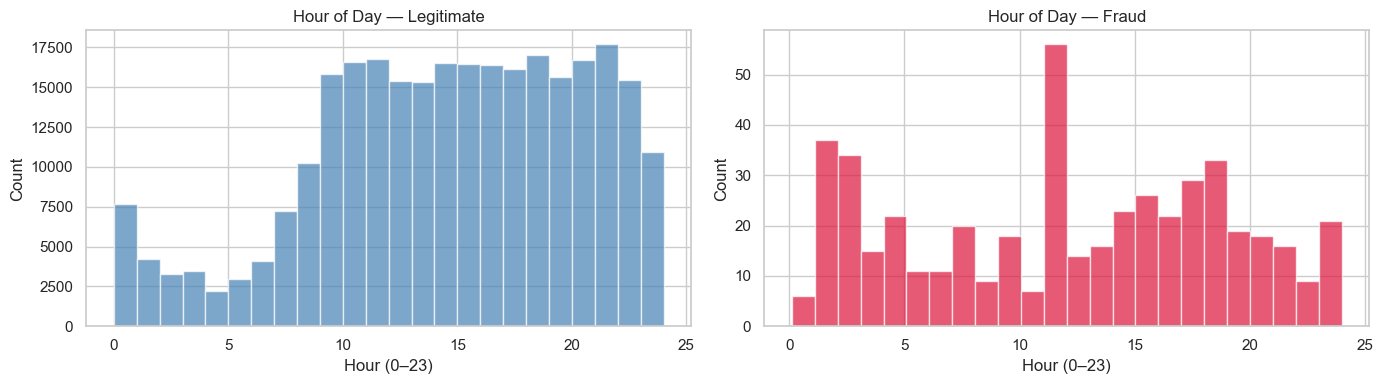

In [3]:
# Modulo 86400 wraps back to 0 at midnight, divide by 3600 converts seconds to hours
df['Hour'] = (df['Time'] % 86400) / 3600
df = df.drop(columns=['Time'])

print(f'Hour range: {df["Hour"].min():.1f} to {df["Hour"].max():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, label, color in zip(axes, ['Legitimate', 'Fraud'], ['steelblue', 'crimson']):
    class_val = 0 if label == 'Legitimate' else 1
    df[df['Class'] == class_val]['Hour'].hist(bins=24, ax=ax, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'Hour of Day — {label}')
    ax.set_xlabel('Hour (0–23)')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Train/Test Split

We split 80/20 with `stratify=y` to ensure both sets maintain the 0.17% fraud ratio. Without stratification, random chance could give us a test set with very few fraud cases — making evaluation unreliable.

**We split before scaling** — this prevents data leakage. The scaler must only learn statistics (mean, std) from training data, never from the test set.

In [4]:
X = df.drop(columns=['Class'])
y = df['Class']

# stratify=y preserves the 0.17% fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]:,} rows')
print(f'Test size:  {X_test.shape[0]:,} rows')
print(f'Train fraud rate: {y_train.mean()*100:.3f}%')
print(f'Test fraud rate:  {y_test.mean()*100:.3f}%')

Train size: 227,845 rows
Test size:  56,962 rows
Train fraud rate: 0.173%
Test fraud rate:  0.172%


## 4. Scale `Amount` and `Hour`

We apply `StandardScaler` to bring `Amount` and `Hour` into the same range as V1–V28.

**Why scaling matters for SMOTE:** SMOTE generates synthetic samples using distance calculations between fraud cases. If `Amount` ranges in the thousands while V features sit between -5 and +5, SMOTE over-weights `Amount` and generates poor synthetic fraud samples — even though features like V14 are far more predictive. Scaling ensures all features contribute equally.

**Data leakage rule:** Fit the scaler on training data only, then apply (transform) to both train and test. If we fit on the full dataset, the scaler would have seen test set values — giving the model information it shouldn't have.

In [5]:
scaler = StandardScaler()

# fit_transform on train: learns mean/std from training data and applies scaling
X_train[['Amount', 'Hour']] = scaler.fit_transform(X_train[['Amount', 'Hour']])

# transform only on test: applies the training mean/std — never re-fits
X_test[['Amount', 'Hour']] = scaler.transform(X_test[['Amount', 'Hour']])

print('After scaling — Amount and Hour stats (train):')
print(X_train[['Amount', 'Hour']].describe().round(3))

After scaling — Amount and Hour stats (train):
           Amount        Hour
count  227845.000  227845.000
mean        0.000       0.000
std         1.000       1.000
min        -0.352      -2.489
25%        -0.329      -0.674
50%        -0.264       0.080
75%        -0.043       0.820
max       102.117       1.619


## 5. Apply SMOTE to Training Data Only

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud examples by interpolating between real fraud cases — giving XGBoost enough fraud examples to learn meaningful patterns.

**Critical rule: SMOTE on training data only.** The test set must reflect real-world distribution (0.17% fraud) so our evaluation metrics are honest. Applying SMOTE to the test set would make the model look better than it actually is in production.

In [6]:
print(f'Before SMOTE — Legitimate: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}')

# random_state=42 ensures reproducibility — same synthetic samples generated every run
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'After SMOTE  — Legitimate: {(y_train_resampled==0).sum():,} | Fraud: {(y_train_resampled==1).sum():,}')
print(f'New fraud rate in training set: {y_train_resampled.mean()*100:.1f}%')

Before SMOTE — Legitimate: 227,451 | Fraud: 394
After SMOTE  — Legitimate: 227,451 | Fraud: 227,451
New fraud rate in training set: 50.0%


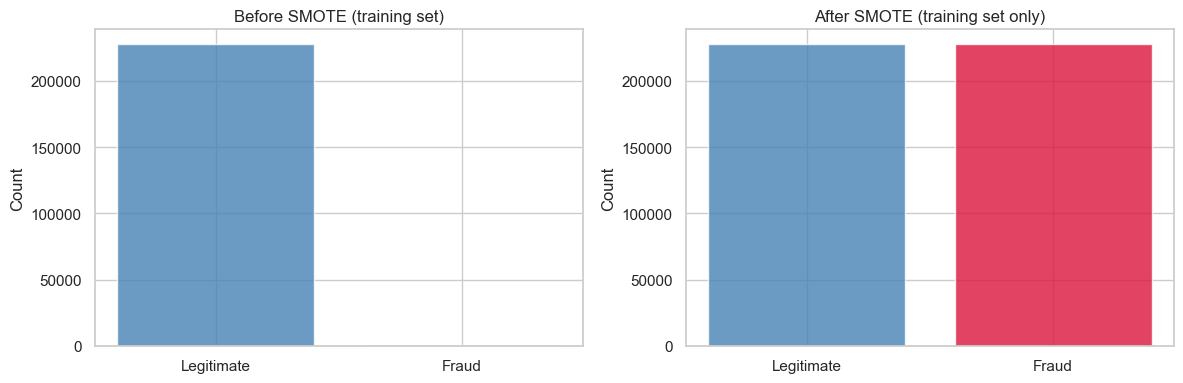

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], [(y_train==0).sum(), (y_train==1).sum()],
            color=['steelblue', 'crimson'], alpha=0.8)
axes[0].set_title('Before SMOTE (training set)')
axes[0].set_ylabel('Count')

axes[1].bar(['Legitimate', 'Fraud'], [(y_train_resampled==0).sum(), (y_train_resampled==1).sum()],
            color=['steelblue', 'crimson'], alpha=0.8)
axes[1].set_title('After SMOTE (training set only)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. Save Processed Datasets

We save four files to `data/processed/`:
- `X_train.csv` / `y_train.csv` — resampled training set (post-SMOTE)
- `X_test.csv` / `y_test.csv` — untouched test set (real-world distribution)

Separating features (X) and labels (y) matches how scikit-learn and XGBoost expect inputs.

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_train_resampled.to_csv('../data/processed/X_train.csv', index=False)
y_train_resampled.to_csv('../data/processed/y_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print('Saved to data/processed/')
print(f'  X_train: {X_train_resampled.shape}')
print(f'  y_train: {y_train_resampled.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_test:  {y_test.shape}')

Saved to data/processed/
  X_train: (454902, 30)
  y_train: (454902,)
  X_test:  (56962, 30)
  y_test:  (56962,)


## 7. Key Takeaways

- `Time` converted to `Hour` (0–23) — more meaningful than raw seconds
- Split before scaling to prevent data leakage
- `Amount` and `Hour` scaled with StandardScaler fitted on training data only
- 80/20 stratified train/test split preserves 0.17% fraud ratio in both sets
- SMOTE applied to training set only — fraud class now balanced at 50%
- Test set left untouched — reflects real-world distribution for honest evaluation
- Processed datasets saved to `data/processed/` — ready for `03_modeling.ipynb`